In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [13]:
# Set graph properties
xaxis_ticks = 20
date_from = "2025-08-01"
date_to = "2025-08-26"
# device_id can be a list
device_id = 1387
# probe is optional
probe = 1


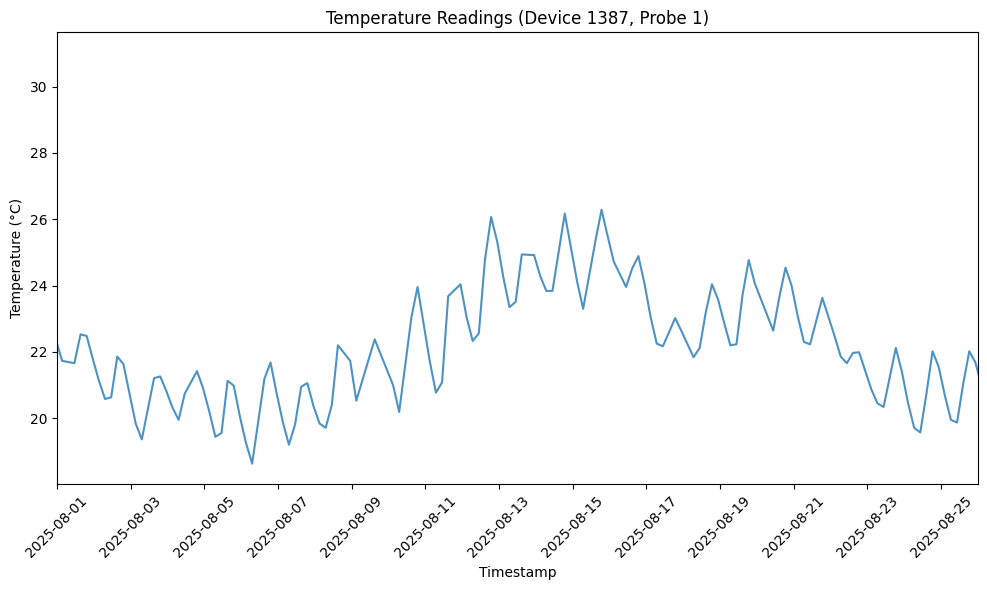

In [14]:
# Connect to the database
conn = sqlite3.connect("database.db")  # replace with your .db file path

# Query the data
query = f"""
SELECT timestamp, temperature
FROM FactSensorData
WHERE device_id = {device_id}
  AND probe_number = {probe}
ORDER BY timestamp;
"""
df = pd.read_sql_query(query, conn)

# Convert timestamp to datetime
df["timestamp"] = df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)

# Plot line plot
plt.figure(figsize=(10, 6))
plt.plot(df["timestamp"], df["temperature"], marker="", linestyle="-", alpha=0.8)
plt.title("Temperature Readings (Device 1387, Probe 1)")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=xaxis_ticks))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xlim(pd.to_datetime("2025-08-01"), pd.to_datetime("2025-08-26"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()